# Clustering and cell type identification

This notebook present a typical pipeline for pre-processing single cell transcriptomics data, as well as for cell type identification

The scRNA-seq data were profiled from healthy human bone-marrow mononuclear cells. 

The notebook has been adapted from the clustering scanpy tutorial: https://scanpy.scverse.org/en/stable/tutorials/basics/clustering.html#

In [1]:
# set up
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import random
%matplotlib inline
random.seed(148)

## Loading and checking the data

In [2]:
# loading data
adata = sc.read_h5ad('adata_group2.h5ad')

In [3]:
adata

AnnData object with n_obs × n_vars = 820 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [4]:
adata.var

,gene_ids
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945
...,...
AC145205.1,ENSG00000215635
BAGE5,ENSG00000268590
CU459201.1,ENSG00000251180
AC002321.2,ENSG00000215616


In [5]:
adata.obs

""
AAACATTGAGCTAC-1
AAACCGTGTATGCG-1
AAACGCTGGTTCTT-1
AAACGCTGTAGCCA-1
AAACTTGAAAAACG-1
...
TTTCAGTGTCACGA-1
TTTCAGTGTGCAGT-1
TTTCTACTGAGGCA-1
TTTCTACTTCCTCG-1


In [6]:
# what scRNA-seq data look like?
print(adata.X[0:24, 0:24].todense())

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.

In [7]:
print(adata.X)

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 656114 stored elements and shape (820, 32738)>
  Coords	Values
  (527, 5)	1.0
  (772, 8)	1.0
  (567, 22)	1.0
  (685, 22)	1.0
  (137, 26)	1.0
  (387, 26)	1.0
  (468, 26)	1.0
  (738, 26)	1.0
  (793, 26)	1.0
  (800, 26)	1.0
  (785, 27)	1.0
  (599, 33)	1.0
  (8, 35)	1.0
  (12, 35)	1.0
  (15, 35)	1.0
  (16, 35)	1.0
  (32, 35)	1.0
  (35, 35)	1.0
  (44, 35)	1.0
  (46, 35)	1.0
  (52, 35)	2.0
  (54, 35)	2.0
  (62, 35)	1.0
  (68, 35)	1.0
  (76, 35)	1.0
  :	:
  (662, 32731)	1.0
  (671, 32731)	1.0
  (733, 32731)	1.0
  (761, 32731)	1.0
  (767, 32731)	2.0
  (777, 32731)	1.0
  (805, 32731)	1.0
  (13, 32732)	1.0
  (32, 32732)	1.0
  (91, 32732)	1.0
  (98, 32732)	1.0
  (197, 32732)	1.0
  (246, 32732)	1.0
  (266, 32732)	1.0
  (325, 32732)	1.0
  (416, 32732)	1.0
  (467, 32732)	1.0
  (483, 32732)	1.0
  (500, 32732)	1.0
  (504, 32732)	1.0
  (511, 32732)	1.0
  (722, 32732)	2.0
  (725, 32732)	1.0
  (734, 32732)	1.0
  (803, 32732)	1.0


In [8]:
print(adata.X[adata.X != 0].mean())
print(adata.X.max())

2.525968
229.0


In [9]:
adata.X.data

array([1., 1., 1., ..., 1., 1., 1.], shape=(656114,), dtype=float32)

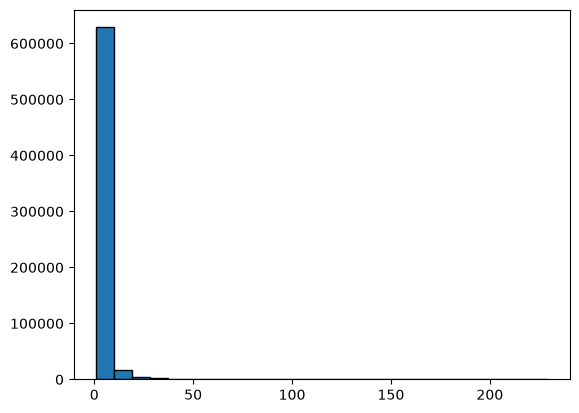

In [10]:
tmp = plt.hist(adata.X.data, bins=25, edgecolor='black')

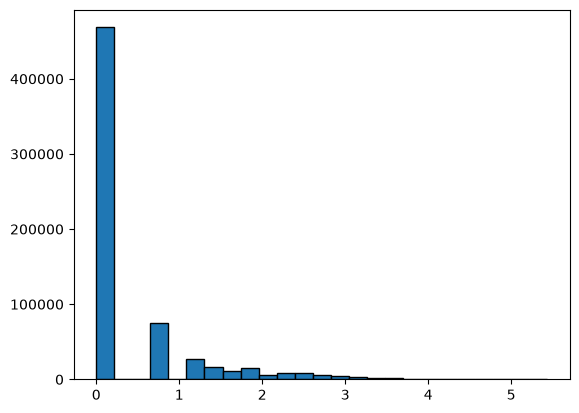

In [11]:
tmp = plt.hist(np.log(adata.X.data), bins=25, edgecolor='black')

In [12]:
# permissive filters
sc.pp.filter_cells(adata, min_genes=100) # Filtering cells with less than 100 genes expressed
sc.pp.filter_genes(adata, min_cells=3) # Filtering genes expressed in less than 3 cells
adata.shape

(820, 11074)

820 × 32738 to 820 × 11074

We remove 21664 genes!

# Quality control

In [13]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=False)

In [14]:
adata.var

,gene_ids,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
LINC00115,ENSG00000225880,6,False,6,0.007317,99.268293,6.0
NOC2L,ENSG00000188976,90,False,90,0.119512,89.024390,98.0
HES4,ENSG00000188290,6,False,6,0.007317,99.268293,6.0
ISG15,ENSG00000187608,290,False,290,0.631707,64.634146,518.0
C1orf159,ENSG00000131591,6,False,6,0.007317,99.268293,6.0
...,...,...,...,...,...,...,...
MT-CYB,ENSG00000198727,761,True,761,3.957317,7.195122,3245.0
AC145212.1,ENSG00000215750,3,False,3,0.003659,99.634146,3.0
AL592183.1,ENSG00000220023,105,False,105,0.147561,87.195122,121.0
PNRC2-1,ENSG00000215700,31,False,31,0.040244,96.219512,33.0


In [15]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt
AAACATTGAGCTAC-1,1352,1344,4876.0,45.754717,61.177194,71.882691,82.690730,186.0,3.814602
AAACCGTGTATGCG-1,522,519,978.0,44.989775,55.828221,67.382413,98.057260,12.0,1.226994
AAACGCTGGTTCTT-1,790,787,2257.0,46.787771,61.896323,72.972973,87.284005,70.0,3.101462
AAACGCTGTAGCCA-1,533,530,1273.0,51.060487,63.000786,74.076984,97.643362,15.0,1.178319
AAACTTGAAAAACG-1,1116,1109,3911.0,44.080798,60.905139,72.692406,84.428535,103.0,2.633598
...,...,...,...,...,...,...,...,...,...
TTTCAGTGTCACGA-1,700,698,1632.0,39.828431,55.882353,69.485294,87.867647,56.0,3.431373
TTTCAGTGTGCAGT-1,637,633,1318.0,39.908953,53.945372,67.147193,89.908953,25.0,1.896813
TTTCTACTGAGGCA-1,1227,1216,3435.0,37.409025,52.081514,64.104803,79.155750,32.0,0.931587
TTTCTACTTCCTCG-1,622,620,1682.0,45.838288,61.712247,75.029727,92.865636,37.0,2.199762


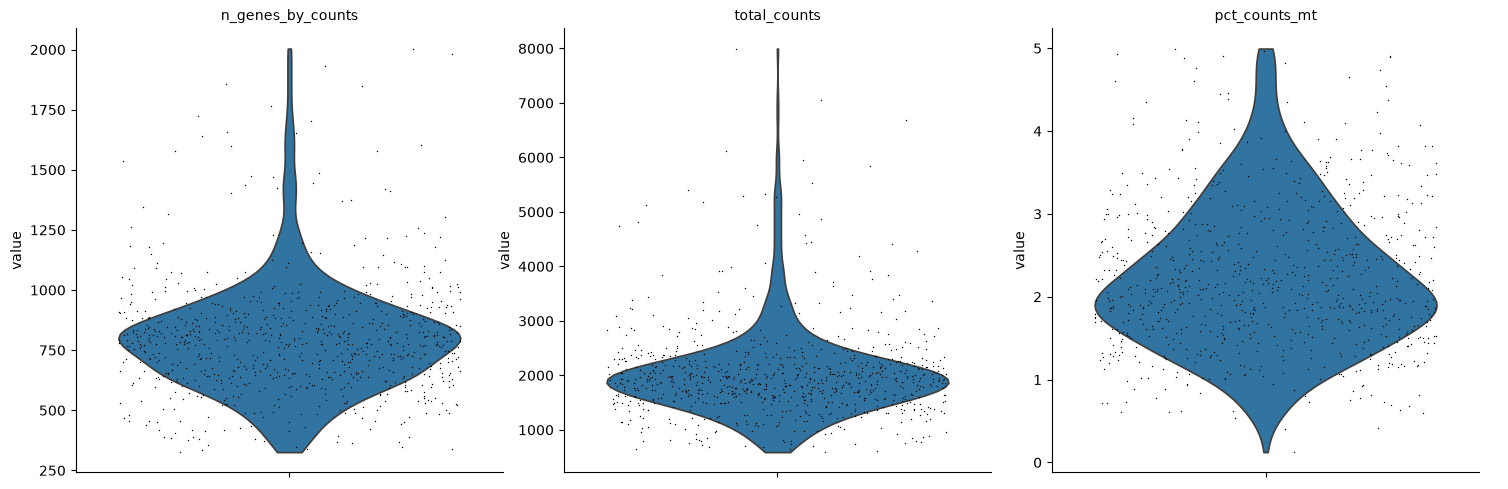

In [16]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [17]:
# QC filters
adata = adata[adata.obs.pct_counts_mt < 4, :]
adata = adata[adata.obs.total_counts < 3000, :]

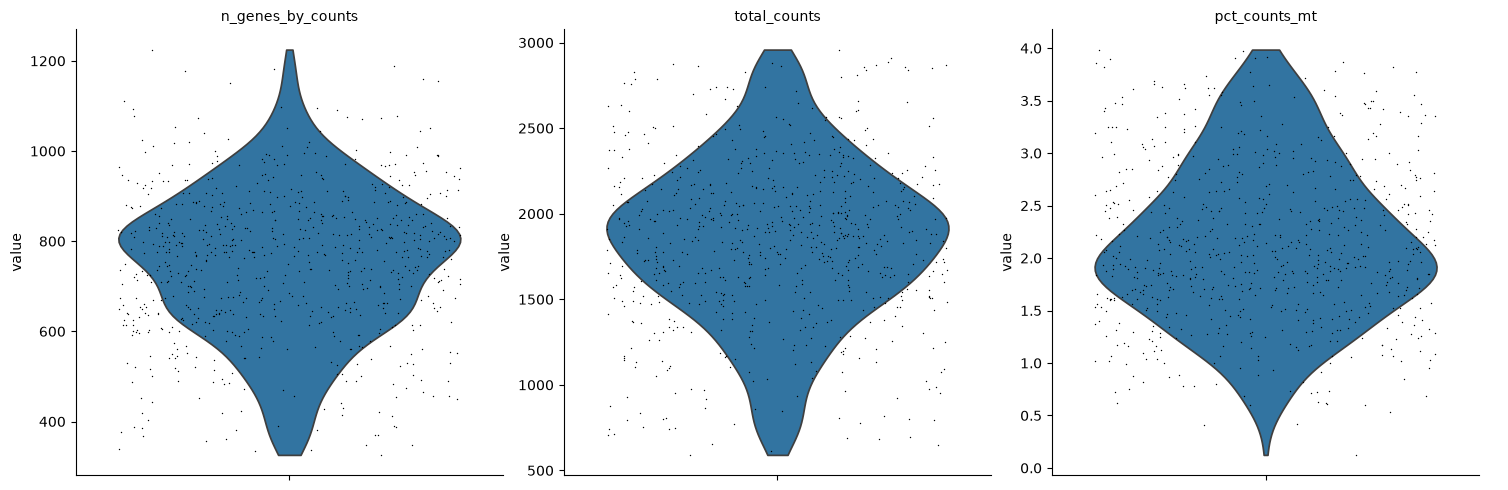

In [18]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [19]:
adata.shape

(727, 11074)

(820 × 32738) to (820 × 11074) to (727 × 11074) 

We remove 93 cells!

## Normalization

In [20]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

/tmp/ipykernel_6297/2262359327.py:2: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata.layers["counts"] = adata.X.copy()


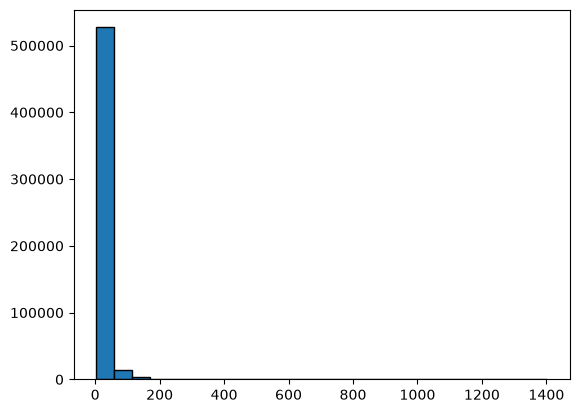

In [21]:
# Normalizing 
sc.pp.normalize_total(adata, target_sum=1e4)
tmp = plt.hist(adata.X.data, bins=25, edgecolor='black')

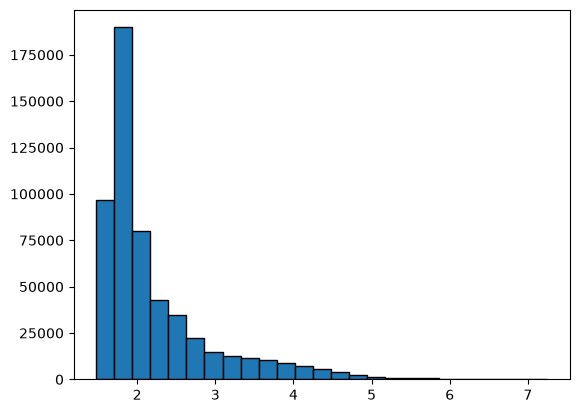

In [22]:
# Logarithmize the data
sc.pp.log1p(adata)
tmp = plt.hist(adata.X.data, bins=25, edgecolor='black')

In [23]:
adata.X[0:10, 0:10].todense()

matrix([[0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 2.181034 , 0.       , 0.       , 2.181034 ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 1.6714084, 0.       ,
         0.       , 0.       , 1.6714084, 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.       , 0.       , 0.       ],
        [0.       , 0.       , 0.       , 0.       , 0.       ,
         0.       , 0.       , 0.

## Feature engineering

In [24]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata.var

,gene_ids,n_cells,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,highly_variable,means,dispersions,dispersions_norm
LINC00115,ENSG00000225880,6,False,6,0.007317,99.268293,6.0,False,0.037486,1.551491,-0.888911
NOC2L,ENSG00000188976,90,False,90,0.119512,89.024390,98.0,False,0.465135,1.787452,-0.423146
HES4,ENSG00000188290,6,False,6,0.007317,99.268293,6.0,False,0.039242,1.776255,-0.096500
ISG15,ENSG00000187608,290,False,290,0.631707,64.634146,518.0,False,1.369844,2.661378,0.260364
C1orf159,ENSG00000131591,6,False,6,0.007317,99.268293,6.0,False,0.030493,1.506677,-1.046906
...,...,...,...,...,...,...,...,...,...,...,...
MT-CYB,ENSG00000198727,761,True,761,3.957317,7.195122,3245.0,False,2.966298,2.497924,-0.369780
AC145212.1,ENSG00000215750,3,False,3,0.003659,99.634146,3.0,False,0.021137,1.723749,-0.281612
AL592183.1,ENSG00000220023,105,False,105,0.147561,87.195122,121.0,False,0.594821,2.000963,-0.397590
PNRC2-1,ENSG00000215700,31,False,31,0.040244,96.219512,33.0,False,0.189030,1.851328,0.168170


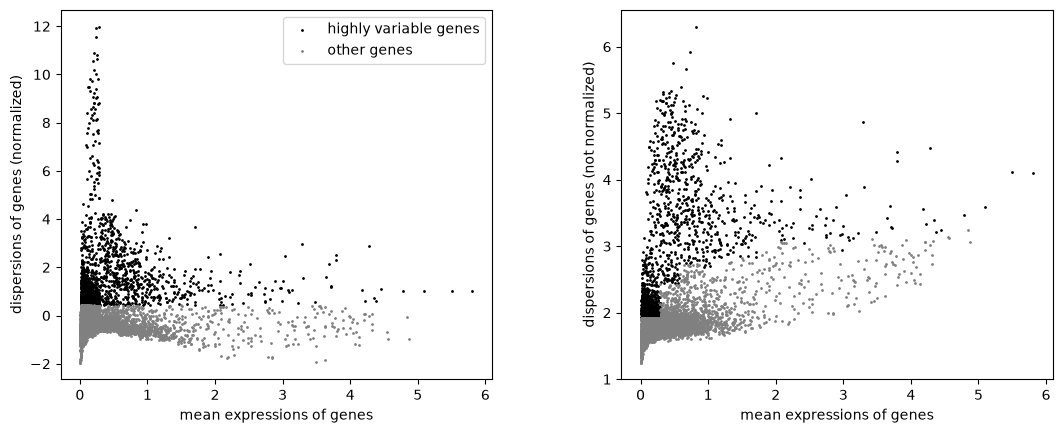

In [25]:
sc.pl.highly_variable_genes(adata)

In [26]:
sc.tl.pca(adata) # by deafault, on highly variable genes

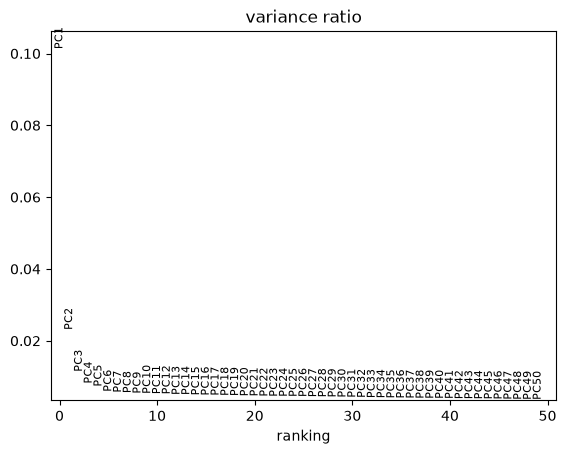

In [27]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=False)

In [28]:
print(adata.obsm['X_pca'][0:5,0:5])
adata.obsm['X_pca'].shape

[[ 7.598421    5.990869   -1.7123802   4.4024754   1.17329   ]
 [ 2.8971963  -5.233738    0.19599454  0.9668105   0.6765659 ]
 [-0.2480142  -1.7805723  -3.6745467   1.3505758   1.6054393 ]
 [ 3.3213737  -6.416033   -3.3647983   2.3944325   1.3467631 ]
 [-8.382595    1.2428154  -3.3610952   2.5053189  -0.8816229 ]]


(727, 50)

## Clustering

In [29]:
sc.pp.neighbors(adata, n_pcs=8)

/home/alejandro/miniconda3/envs/mfe/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [30]:
sc.tl.leiden(adata, flavor="igraph", resolution=0.3)

In [31]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,leiden
AAACCGTGTATGCG-1,522,519,978.0,44.989775,55.828221,67.382413,98.057260,12.0,1.226994,0
AAACGCTGGTTCTT-1,790,787,2257.0,46.787771,61.896323,72.972973,87.284005,70.0,3.101462,1
AAACGCTGTAGCCA-1,533,530,1273.0,51.060487,63.000786,74.076984,97.643362,15.0,1.178319,2
AAAGAGACGGACTT-1,458,455,1149.0,51.958225,65.100087,77.806789,100.000000,27.0,2.349869,2
AAAGTTTGATCACG-1,446,440,1264.0,53.560127,70.174051,81.012658,100.000000,44.0,3.481013,3
...,...,...,...,...,...,...,...,...,...,...
TTTCAGTGGAAGGC-1,692,687,1776.0,47.635135,61.373874,72.578829,89.470721,27.0,1.520270,1
TTTCAGTGTCACGA-1,700,698,1632.0,39.828431,55.882353,69.485294,87.867647,56.0,3.431373,3
TTTCAGTGTGCAGT-1,637,633,1318.0,39.908953,53.945372,67.147193,89.908953,25.0,1.896813,3
TTTCTACTTCCTCG-1,622,620,1682.0,45.838288,61.712247,75.029727,92.865636,37.0,2.199762,3


## Visualization

In [32]:
sc.set_figure_params(dpi=100, facecolor="white", figsize=(8,8))

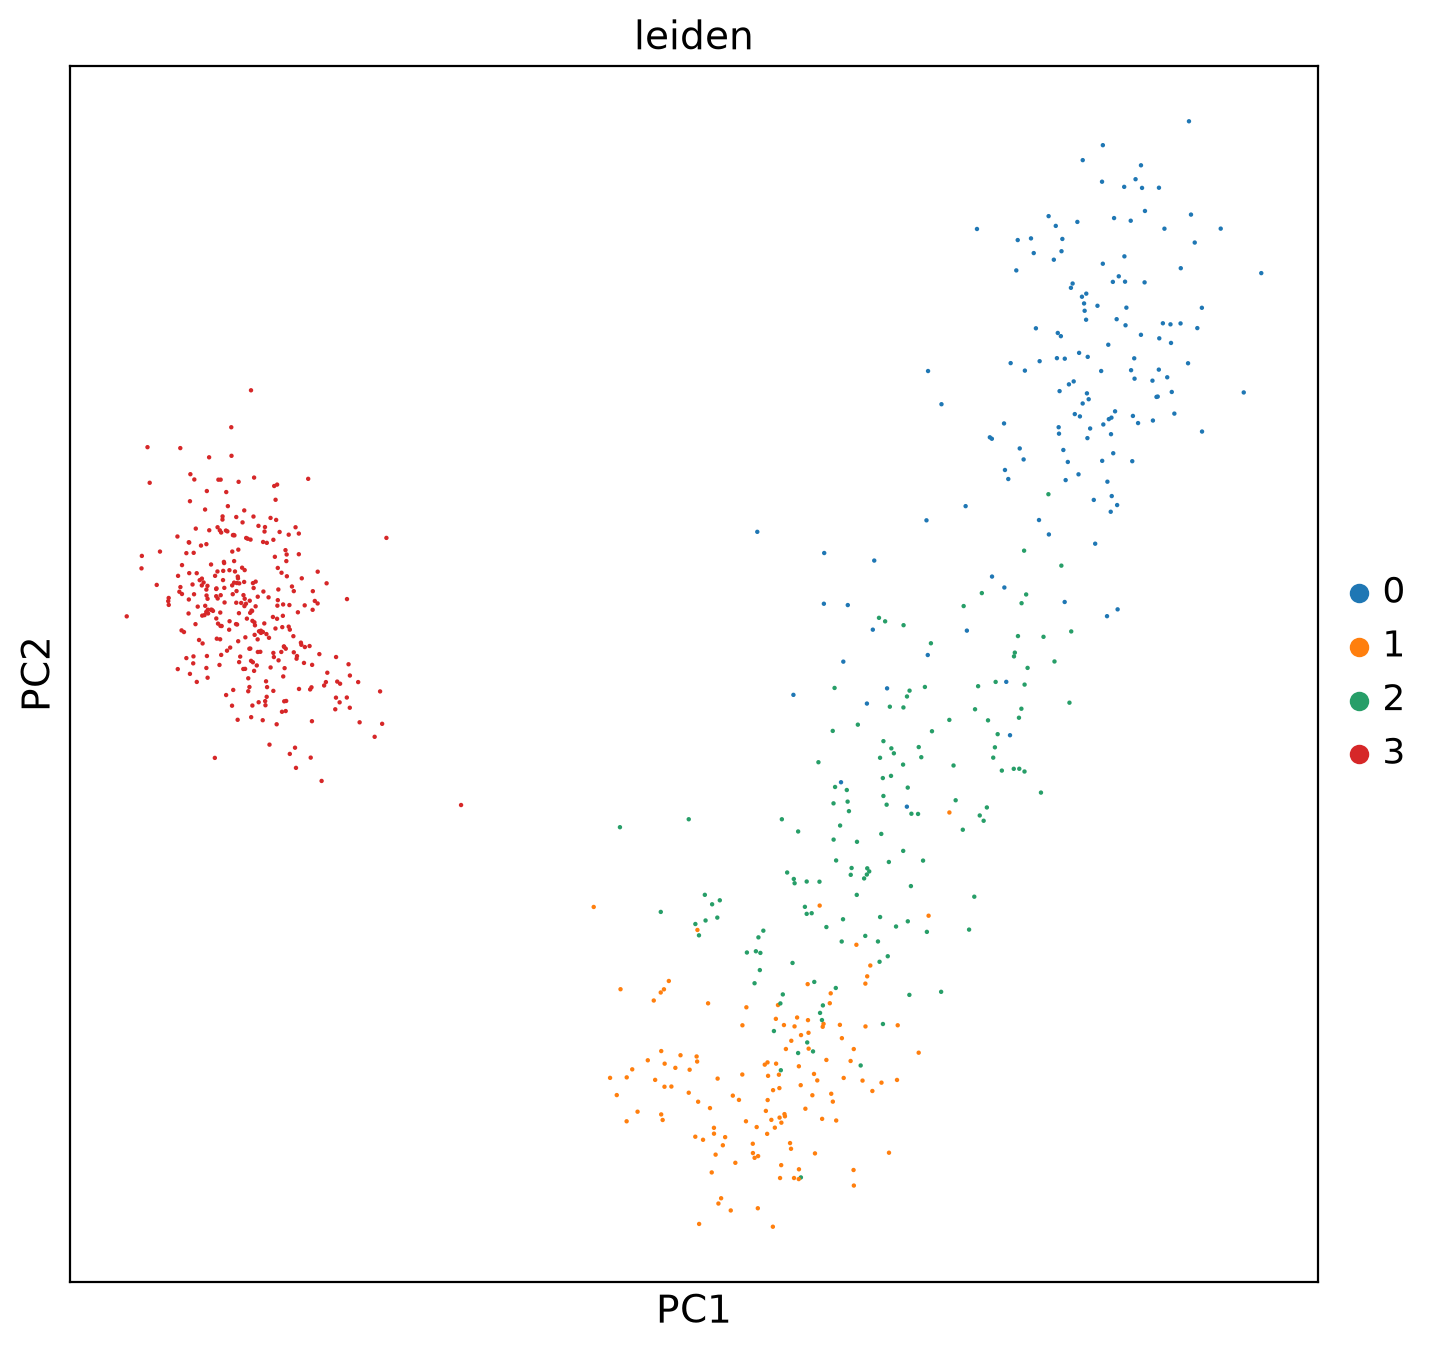

In [33]:
sc.pl.pca(adata, color = "leiden", size=10)

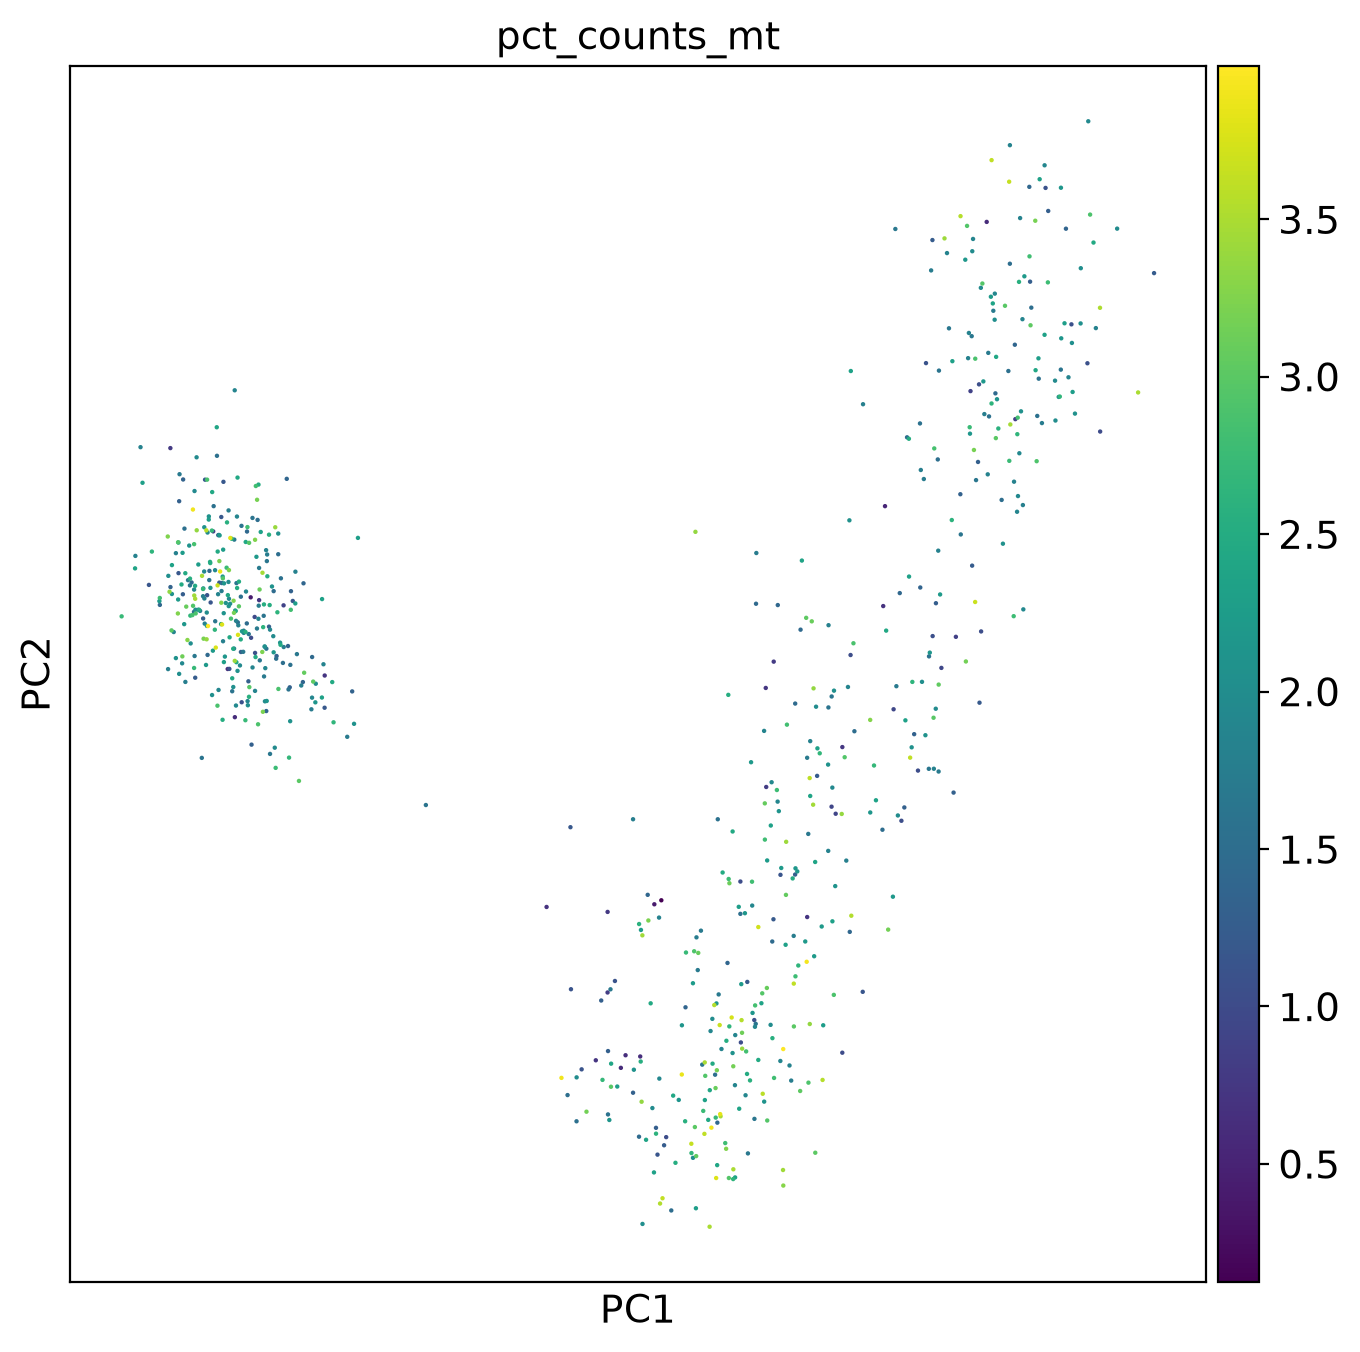

In [34]:
sc.pl.pca(adata, color = "pct_counts_mt", size=10)

In [35]:
sc.tl.umap(adata)

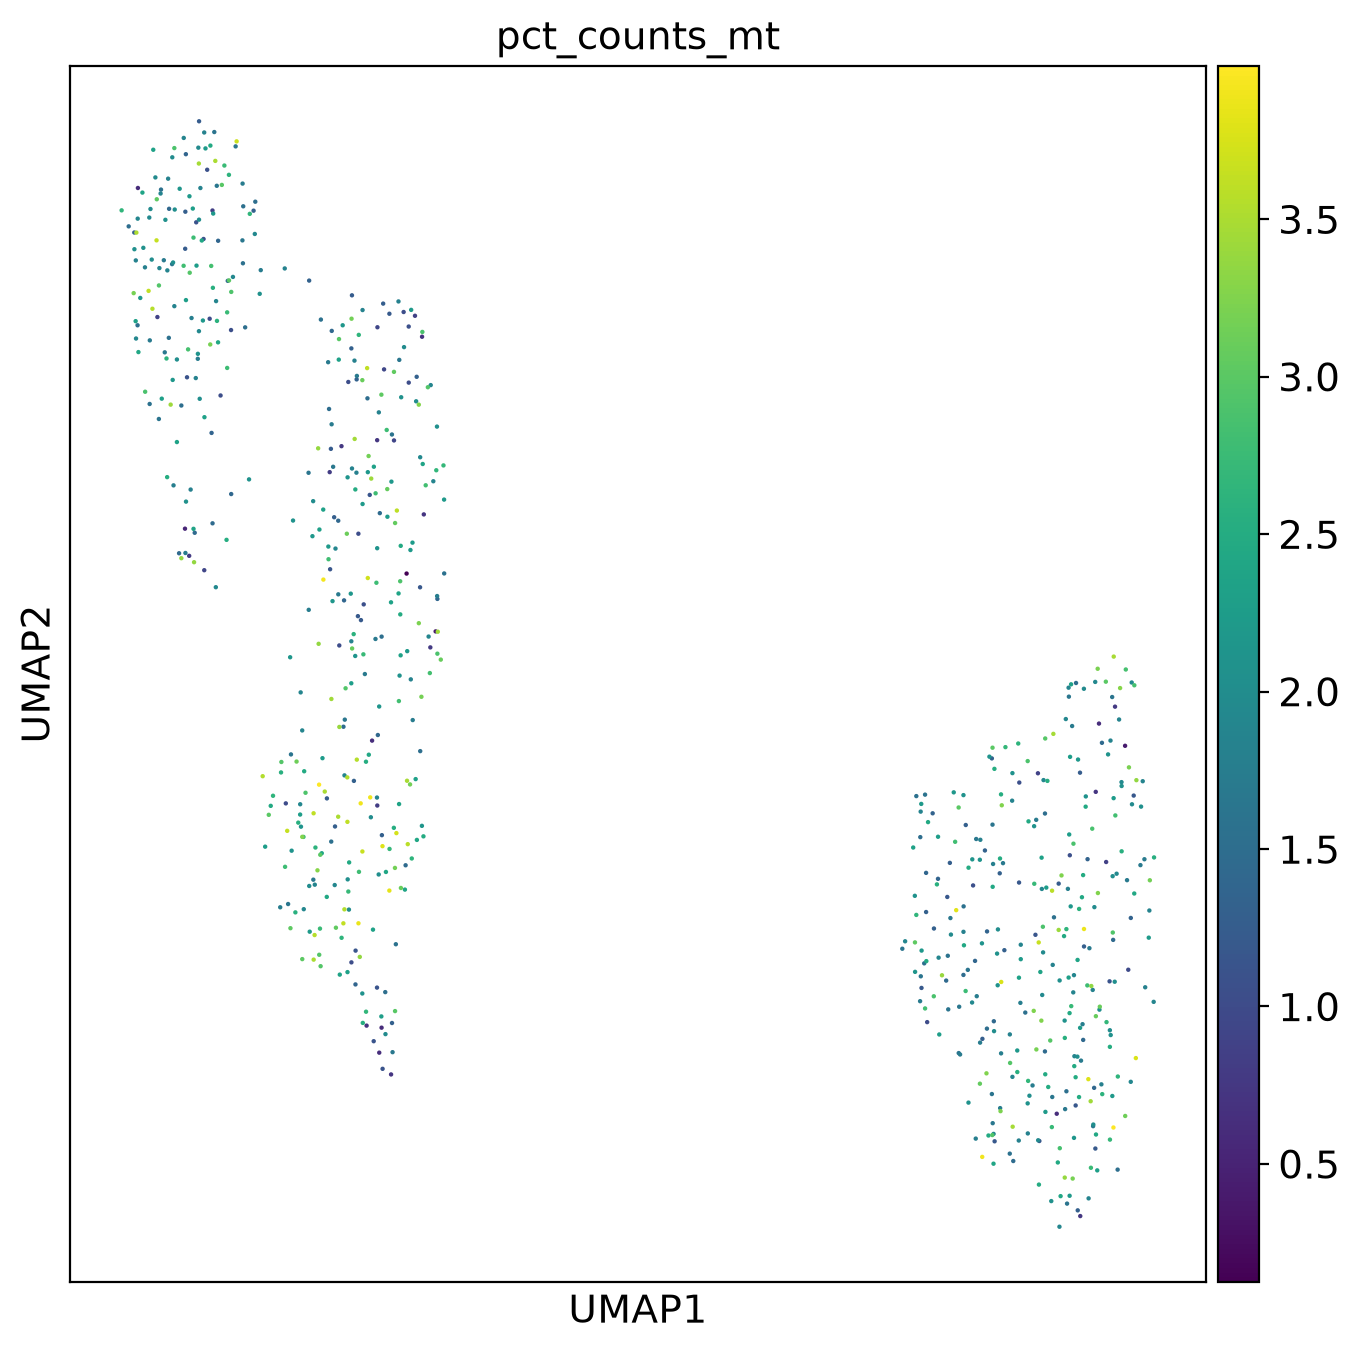

In [36]:
sc.pl.umap(adata, color="pct_counts_mt", size=10)

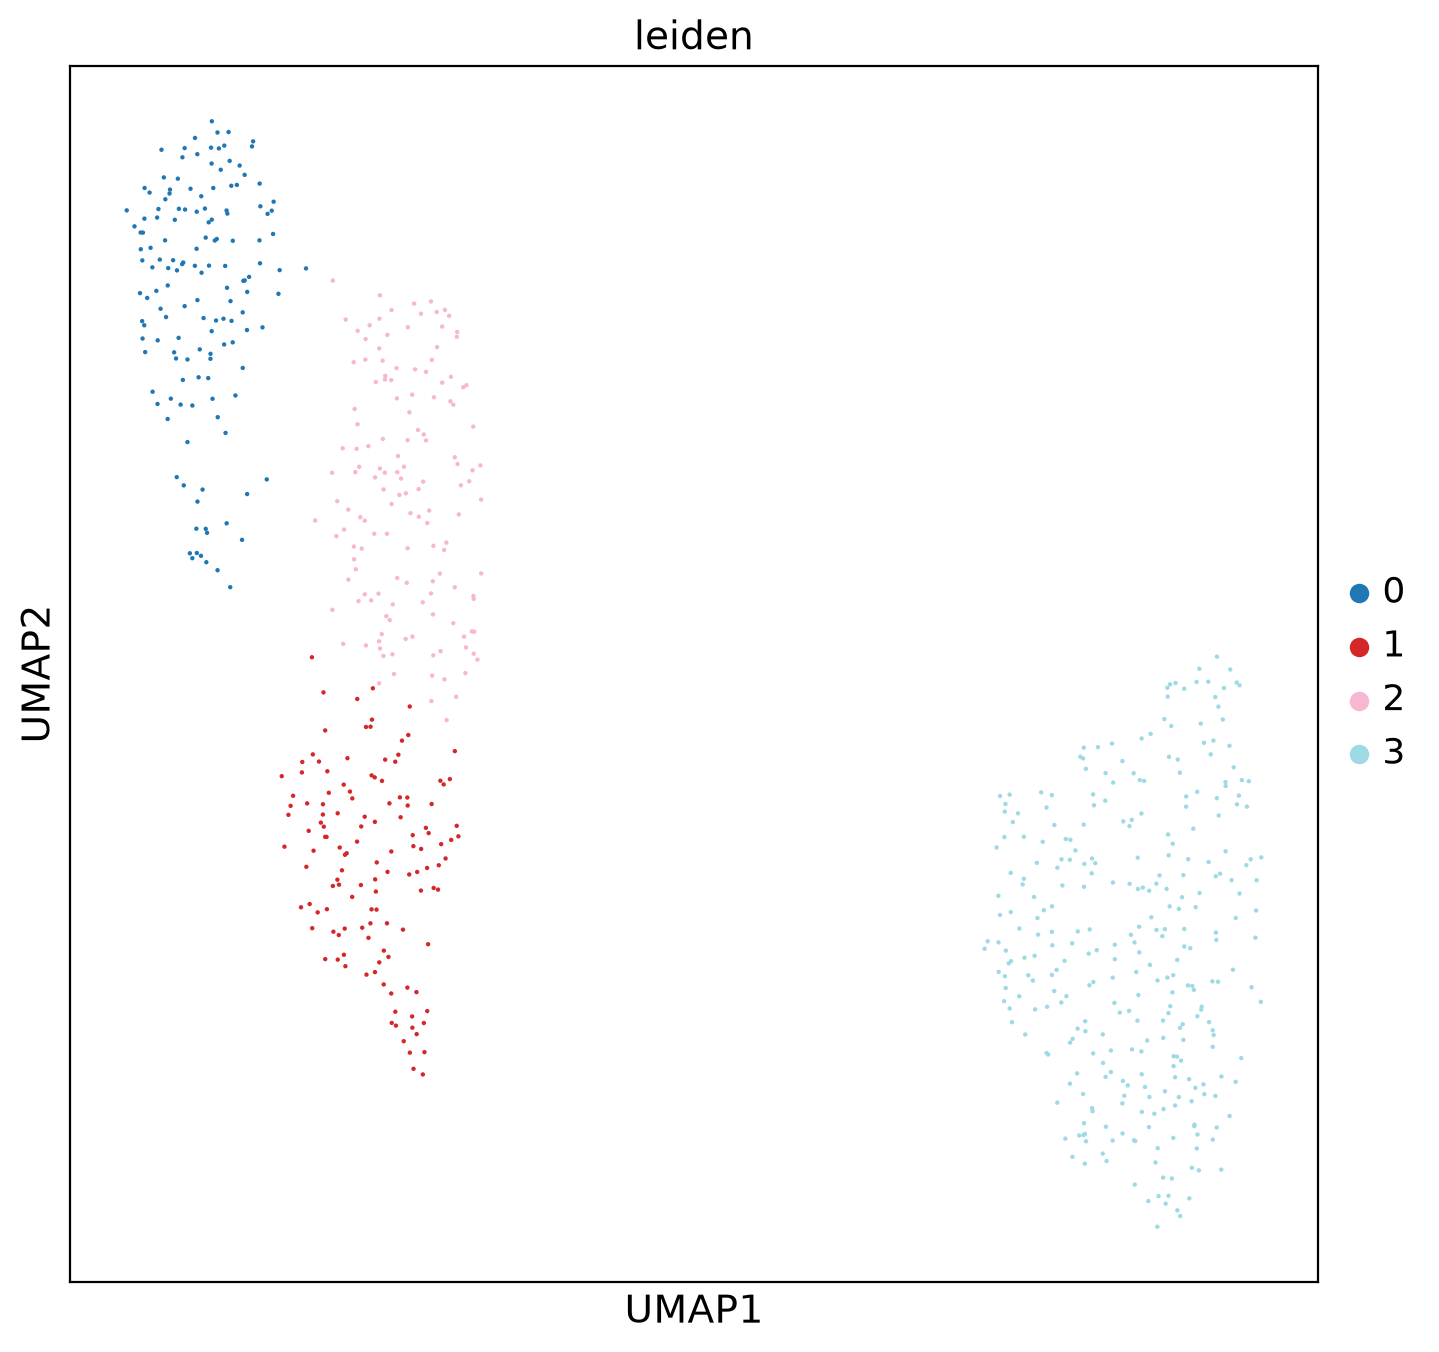

In [37]:
sc.pl.umap(adata, color = "leiden", size=10, palette='tab20')

## Cell type identification

In [38]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

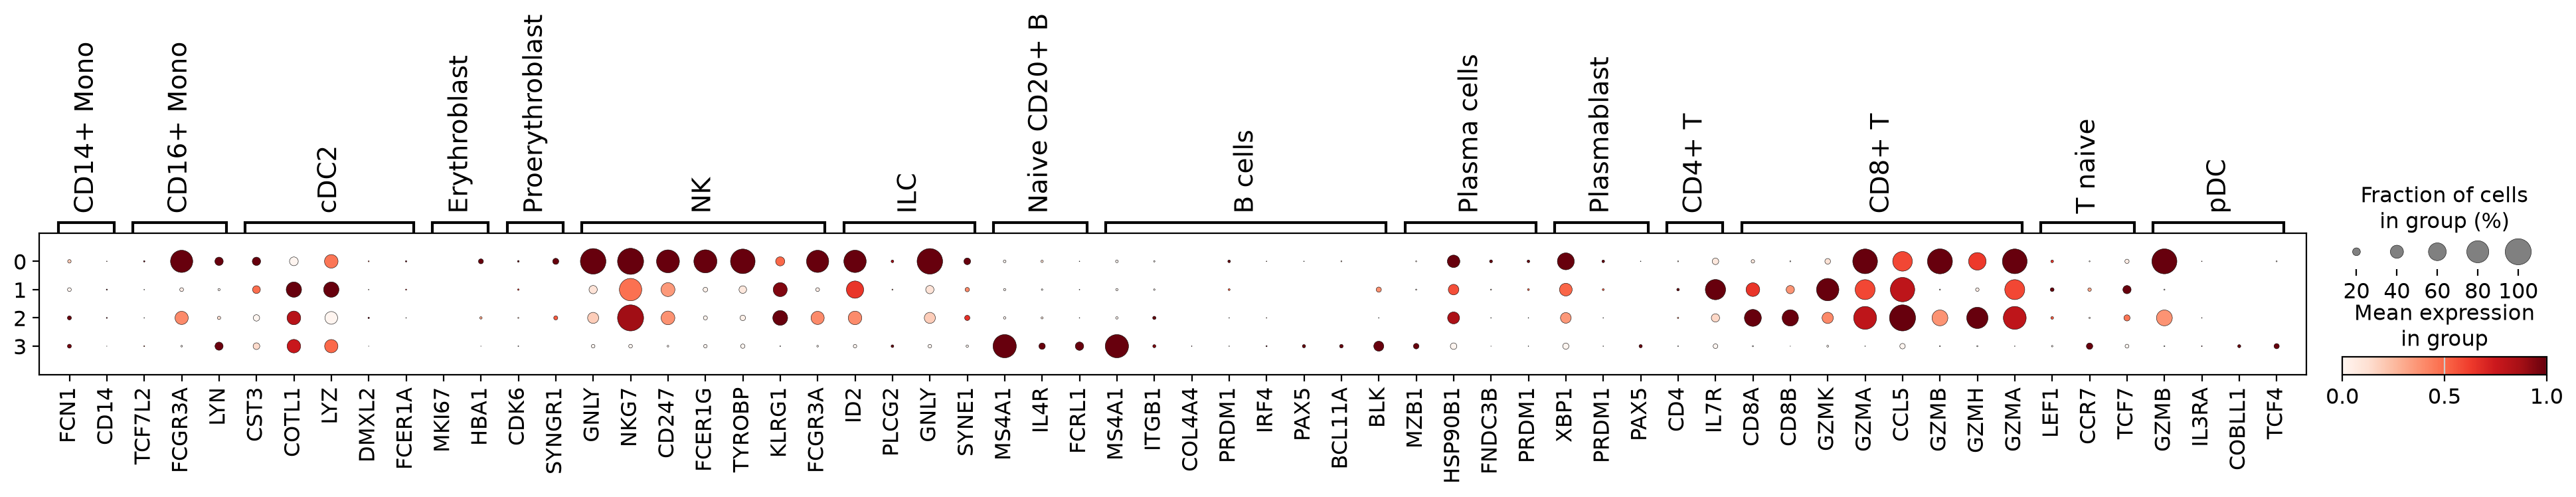

In [40]:
filtered_marker_genes = {}
# Ensure existing_genes contains standard Python strings
existing_genes = set(str(g) for g in adata.var_names)

for cell_type, genes in marker_genes.items():
    # Ensure genes being checked are also standard Python strings
    filtered_genes = [str(gene) for gene in genes if str(gene) in existing_genes]
    if filtered_genes:
        filtered_marker_genes[cell_type] = filtered_genes

sc.pl.dotplot(adata, filtered_marker_genes, groupby="leiden", standard_scale="var")